#Project 9 - Βαθιά Ενισχυτική Μάθηση


Κωνσταντίνα Μαρίνα Μπλέτσα, ΑΕΜ 243

1. Libraries Installation

In [1]:
!pip install swig


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.8 MB/s eta 0:00:00


In [2]:
!pip install gymnasium[box2d]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2398781 sha256=771a17cee2d726b8457d9b28e4ca54b359c546207a9dcc4ea6dc15c7302ca9f7
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py


In [3]:
!pip install ray[rllib]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.4/965.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 14.8 MB/s eta 0:00:00
  Attempting uninstall: ormsgpack
    Found existing installation: ormsgpack 1.12.1
    Uninstalling ormsgpack-1.12.1:
      Successfully uninstalled ormsgpack-1.12.1
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.2
    Uninstalling gymnasium-1.2.2:
      Successfully uninstalled gymnasium-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-checkpoi

In [4]:
!pip install renderlab

2. Συναρτήσεις: step, reset, render

Η συνάρτηση reset() στο Gymnasium χρησιμοποιείται για να επαναφέρει το περιβάλλον στην αρχική του κατάσταση πριν ξεκινήσει ένα νέο επεισόδιο. Πρέπει να καλείται πριν από την πρώτη κλήση της step(), ώστε να επιστραφεί η αρχική παρατήρηση του περιβάλλοντος και επιπλέον πληροφορίες (info). Η reset() μπορεί επίσης να δεχθεί προαιρετικά ένα seed για να καθορίσει τον τρόπο με τον οποίο αρχικοποιείται ο τυχαίος αριθμός του περιβάλλοντος.

Η συνάρτηση step(action) χρησιμοποιείται για να εκτελέσει ένα βήμα προσομοίωσης στο περιβάλλον με βάση την ενέργεια (action) που αποφασίζει ο πράκτορας. Αυτή η συνάρτηση ενημερώνει την εσωτερική κατάσταση του περιβάλλοντος και επιστρέφει πέντε στοιχεία: την επόμενη παρατήρηση (observation), την ανταμοιβή (reward) που παρέχεται για την ενέργεια, δύο λογικές μεταβλητές (terminated και truncated) που δείχνουν αν το επεισόδιο τελείωσε και αν έληξε λόγω χρονικού ορίου αντίστοιχα, καθώς και ένα λεξικό info με συμπληρωματικές διαγνωστικές πληροφορίες. Όταν το περιβάλλον εισέλθει σε τερματικό ή τετραγωνισμένο (truncated) στάδιο, απαιτείται η επαναφορά του με reset() πριν από άλλες κλήσεις στο step().

Η συνάρτηση render() χρησιμοποιείται για οπτικοποίηση του περιβάλλοντος, ώστε ο χρήστης να βλέπει την τρέχουσα κατάσταση γραφικά ή σε άλλη μορφή εξόδου. Η render() επιτρέπει στον χρήστη να παρακολουθεί την πρόοδο του πράκτορα και να ελέγχει οπτικά τη συμπεριφορά της πολιτικής του κατά τη διάρκεια της εκτέλεσης.

3. Περιβάλλον LunarLander-v3 (Observation Space, Action Space, Reward Function)


Το περιβάλλον LunarLander-v3 προσομοιώνει την προσγείωση ενός διαστημοπλοίου σε συγκεκριμένο σημείο στην επιφάνεια της Σελήνης, ο πράκτορας παρατηρεί την κατάσταση του σκάφους και επιλέγει ενέργειες με στόχο την επιτυχημένη προσγείωση.

Το Observation Space του περιβάλλοντος αποτελείται από ένα διάνυσμα 8 συνεχών πραγματικών τιμών που περιγράφουν την κατάσταση του διαστημοπλοίου. Περιλαμβάνει την οριζόντια και κατακόρυφη θέση του σκάφους, την οριζόντια και κατακόρυφη ταχύτητά του, τη γωνία προσανατολισμού, τη γωνιακή ταχύτητα, καθώς και δύο δυαδικές μεταβλητές που υποδεικνύουν αν το αριστερό και το δεξί σκέλος του σκάφους βρίσκονται σε επαφή με το έδαφος. Όλες οι τιμές είναι κανονικοποιημένες ώστε να διευκολύνεται η εκπαίδευση του πράκτορα.

Το Action Space αποτελείται από τέσσερις δυνατές ενέργειες, ο πράκτορας μπορεί να μην ενεργοποιήσει κανέναν κινητήρα, να ενεργοποιήσει τον κύριο κατακόρυφο κινητήρα, να ενεργοποιήσει τον αριστερό κινητήρα ή να ενεργοποιήσει τον δεξί κινητήρα. Με αυτές τις ενεργειες, ο πράκτορας ελέγχει την κάθοδο, τη σταθερότητα και τον προσανατολισμό του διαστημοπλοίου στην προσγείωση.

Η Reward Function του LunarLander-v3 υπάρχει για να ενθαρρύνει την σωστή προσγείωση. Ο πράκτορας λαμβάνει θετική ανταμοιβή όταν πλησιάζει το σημείο προσγείωσης, αντίθετα, τιμωρείται όταν χρησιμοποιεί υπερβολικά τους κινητήρες, όταν απομακρύνεται από την περιοχή στόχο ή όταν έχει μεγάλη ταχύτητα και αστάθεια. Αν κάνει επιτυχημένη προσγείωση δίνεται μεγάλη θετική ανταμοιβή, ενώ σε περίπτωση συντριβής ή αποτυχημένης προσγείωσης του δίνεται μεγάλη αρνητική ανταμοιβή τιμωρία.

4. Δημιουργία ενός random agent

In [10]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np

In [11]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

env = RecordVideo(
    env,
    video_folder="./videos",
    episode_trigger=lambda episode_id: True,
    name_prefix="random_agent"
)

In [12]:
observation, info = env.reset()
done = False
episode_reward = 0

while not done:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    done = terminated or truncated

env.close()
episode_reward

np.float64(-311.8019656949301)

5. Random agent για 5 επεισόδια

In [13]:
env = gym.make("LunarLander-v3")
episode_rewards = []

for episode in range(5):
    observation, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated

    episode_rewards.append(total_reward)
    print(f"Episode {episode + 1} reward: {total_reward:.2f}")

env.close()

Episode 1 reward: -163.44
Episode 2 reward: -124.19
Episode 3 reward: -201.80
Episode 4 reward: -72.20
Episode 5 reward: -321.66


In [14]:
mean_score = np.mean(episode_rewards)
print(f"\nΜέσο score random agent (5 επεισόδια): {mean_score:.2f}")


Μέσο score random agent (5 επεισόδια): -176.66


6. Εκπαιδευση αλγορίθμων DQN και PPO


In [15]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.4 MB/s eta 0:00:00


In [16]:
import gymnasium as gym
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.env_util import make_vec_env

  return datetime.utcnow().replace(tzinfo=utc)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [17]:
env = make_vec_env("LunarLander-v3", n_envs=1)

Εκπαίδευση DQN

In [18]:
dqn_model = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=1_000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

dqn_model.learn(total_timesteps=100_000)

Using cpu device


  return datetime.utcnow().replace(tzinfo=utc)



----------------------------------
| rollout/            |          |
|    ep_len_mean      | 102      |
|    ep_rew_mean      | -215     |
|    exploration_rate | 0.961    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3004     |
|    time_elapsed     | 0        |
|    total_timesteps  | 406      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 88.6     |
|    ep_rew_mean      | -168     |
|    exploration_rate | 0.933    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2943     |
|    time_elapsed     | 0        |
|    total_timesteps  | 709      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 83.3     |
|    ep_rew_mean      | -147     |
|    exploration_rate | 0.905    |
| time/               |          |
|    episodes       

Εκπαίδευση PPO

In [19]:
ppo_model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

ppo_model.learn(total_timesteps=100_000)

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 92.3     |
|    ep_rew_mean     | -153     |
| time/              |          |
|    fps             | 901      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 92.3        |
|    ep_rew_mean          | -163        |
| time/                   |             |
|    fps                  | 567         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006540319 |
|    clip_fraction        | 0.0217      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.00214     |
|    learning

7. Συγκριση των Αποτελεσμάτων των 2 Αλγοριθμων

In [21]:
def evaluate_agent(model, env_id="LunarLander-v3", n_episodes=5):
    env = gym.make(env_id)
    episode_rewards = []

    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        episode_rewards.append(total_reward)

    env.close()
    return np.mean(episode_rewards), episode_rewards

In [22]:
dqn_mean, dqn_rewards = evaluate_agent(dqn_model)
ppo_mean, ppo_rewards = evaluate_agent(ppo_model)

print(f"Μέσο reward DQN (5 επεισόδια): {dqn_mean:.2f}")
print(f"Μέσο reward PPO (5 επεισόδια): {ppo_mean:.2f}")


Μέσο reward DQN (5 επεισόδια): -118.10
Μέσο reward PPO (5 επεισόδια): 50.63


7.1) Χρόνος εκπαίδευσης των 2 αλγοριθμων

In [23]:
import time

In [24]:
start_time = time.time()
dqn_model.learn(total_timesteps=100_000)
dqn_time = time.time() - start_time

start_time = time.time()
ppo_model.learn(total_timesteps=100_000)
ppo_time = time.time() - start_time

print(f"DQN training time: {dqn_time:.2f} sec")
print(f"PPO training time: {ppo_time:.2f} sec")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 105      |
|    ep_rew_mean      | -204     |
|    exploration_rate | 0.96     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2681     |
|    time_elapsed     | 0        |
|    total_timesteps  | 420      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 99.8     |
|    ep_rew_mean      | -243     |
|    exploration_rate | 0.924    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2694     |
|    time_elapsed     | 0        |
|    total_timesteps  | 798      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 104      |
|    ep_rew_mean      | -210     |
|    exploration_rate | 0.882    |
| time/               |          |
|    episodes       

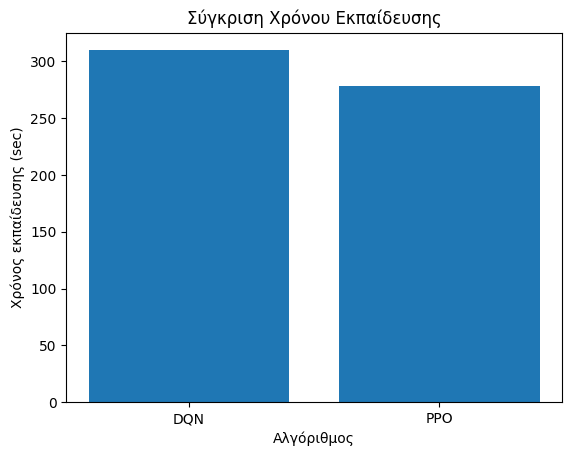

In [25]:
import matplotlib.pyplot as plt

algorithms = ["DQN", "PPO"]
training_times = [dqn_time, ppo_time]

plt.figure()
plt.bar(algorithms, training_times)
plt.xlabel("Αλγόριθμος")
plt.ylabel("Χρόνος εκπαίδευσης (sec)")
plt.title("Σύγκριση Χρόνου Εκπαίδευσης")
plt.show()

7.2) Rewards των 2 αλγοριθμων ανά βήμα/επεισόδιο

In [30]:
import gymnasium as gym
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import DQN, PPO
import matplotlib.pyplot as plt

In [31]:
env_dqn = Monitor(gym.make("LunarLander-v3"))
env_ppo = Monitor(gym.make("LunarLander-v3"))

In [32]:
dqn_plot_model = DQN(
    "MlpPolicy",
    env_dqn,
    learning_rate=1e-3,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    gamma=0.99,
    verbose=0
)

dqn_plot_model.learn(total_timesteps=100_000)

In [33]:
ppo_plot_model = PPO(
    "MlpPolicy",
    env_ppo,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=0
)

ppo_plot_model.learn(total_timesteps=100_000)


In [34]:
dqn_episode_rewards = env_dqn.get_episode_rewards()
ppo_episode_rewards = env_ppo.get_episode_rewards()

print(len(dqn_episode_rewards), len(ppo_episode_rewards))

213 380


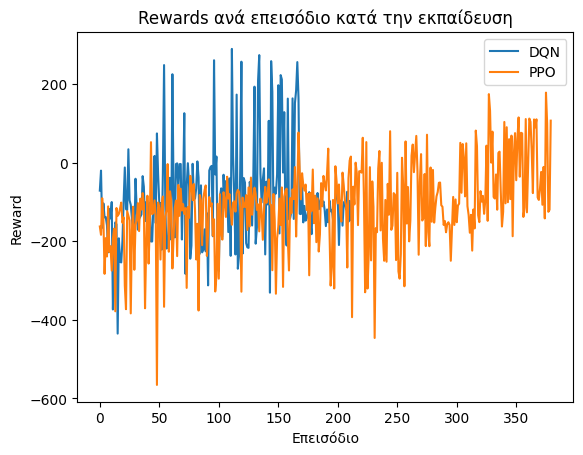

In [35]:
plt.figure()
plt.plot(dqn_episode_rewards, label="DQN")
plt.plot(ppo_episode_rewards, label="PPO")
plt.xlabel("Επεισόδιο")
plt.ylabel("Reward")
plt.title("Rewards ανά επεισόδιο κατά την εκπαίδευση")
plt.legend()
plt.show()

8. Επανεκπαίδευση των DQN και PPO με κατάλληλες παραμέτρους

In [36]:
def evaluate_agent(model, env_id="LunarLander-v3", n_episodes=5):
    env = gym.make(env_id)
    rewards = []

    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    env.close()
    return np.mean(rewards), rewards


In [37]:
env_dqn = Monitor(gym.make("LunarLander-v3"))
env_ppo = Monitor(gym.make("LunarLander-v3"))

8.1) DQN – Tuned Hyperparameters

In [38]:
start_time = time.time()

dqn_tuned = DQN(
    "MlpPolicy",
    env_dqn,
    learning_rate=2e-4,
    buffer_size=100_000,
    learning_starts=5_000,
    batch_size=128,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1_000,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    verbose=1
)

dqn_tuned.learn(total_timesteps=200_000)

dqn_time = time.time() - start_time
print(f"DQN tuned training time: {dqn_time:.2f} sec")

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 92.2     |
|    ep_rew_mean      | -160     |
|    exploration_rate | 0.982    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5019     |
|    time_elapsed     | 0        |
|    total_timesteps  | 369      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.5     |
|    ep_rew_mean      | -172     |
|    exploration_rate | 0.965    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4893     |
|    time_elapsed     | 0        |
|    total_timesteps  | 732      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 94.7     |
|    ep_rew_mean      | -217     |
|    exploration_rate | 0.946    |
| t

8.2) PPO – Tuned Hyperparameters

In [39]:
start_time = time.time()

ppo_tuned = PPO(
    "MlpPolicy",
    env_ppo,
    n_steps=1024,
    batch_size=64,
    n_epochs=4,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    learning_rate=3e-4,
    verbose=1
)

ppo_tuned.learn(total_timesteps=200_000)

ppo_time = time.time() - start_time
print(f"PPO tuned training time: {ppo_time:.2f} sec")

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94.2     |
|    ep_rew_mean     | -117     |
| time/              |          |
|    fps             | 1034     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 96.4         |
|    ep_rew_mean          | -186         |
| time/                   |              |
|    fps                  | 903          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0021559438 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.39        |
|    e

Αξιολογηση-Γραφήματα

In [40]:
dqn_mean, dqn_eval_rewards = evaluate_agent(dqn_tuned)
ppo_mean, ppo_eval_rewards = evaluate_agent(ppo_tuned)

print(f"Μέσο reward DQN (tuned, 5 επεισόδια): {dqn_mean:.2f}")
print(f"Μέσο reward PPO (tuned, 5 επεισόδια): {ppo_mean:.2f}")

Μέσο reward DQN (tuned, 5 επεισόδια): 182.08
Μέσο reward PPO (tuned, 5 επεισόδια): -75.97


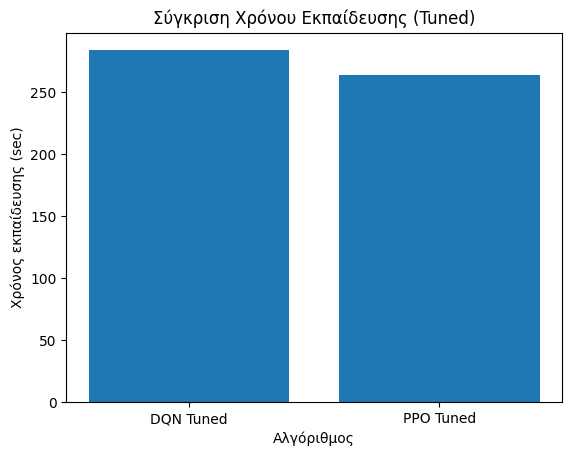

In [41]:
plt.figure()
plt.bar(["DQN Tuned", "PPO Tuned"], [dqn_time, ppo_time])
plt.xlabel("Αλγόριθμος")
plt.ylabel("Χρόνος εκπαίδευσης (sec)")
plt.title("Σύγκριση Χρόνου Εκπαίδευσης (Tuned)")
plt.show()

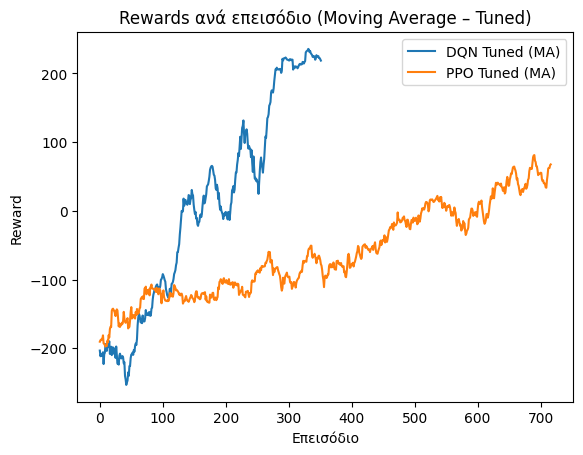

In [43]:
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode="valid")

plt.figure()
plt.plot(moving_average(dqn_episode_rewards), label="DQN Tuned (MA)")
plt.plot(moving_average(ppo_episode_rewards), label="PPO Tuned (MA)")
plt.xlabel("Επεισόδιο")
plt.ylabel("Reward")
plt.title("Rewards ανά επεισόδιο (Moving Average – Tuned)")
plt.legend()
plt.show()